In [1]:
# Install libraries 
!pip install seaborn --quiet
!pip install missingno --quiet
!pip install imblearn --quiet
!pip install scikit-learn --quiet

In [2]:
import os 
import sys
import pandas as pd 
import seaborn as sns
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import warnings

sys.path.append(os.path.abspath(".."))

# Import functions 
import functions.wrangling as wrg
import functions.missing_labs as ml
import functions.eda as eda
import functions.eda_model as em

warnings.filterwarnings("ignore")

In [3]:
df_all_vars = ml.load_data("bd_labs_after_cleaned_all.csv")
# Standardize the 'PerformedDate' by converting it to a 'VisitOrder' variable, grouping by patient and ordering their lab test records chronologically
df_all_vars = df_all_vars.sort_values(['Patient_ID', 'PerformedDate'])
df_all_vars['VisitOrder'] = df_all_vars.groupby('Patient_ID').cumcount() + 1

Loaded dataset with shape: (1196, 11)


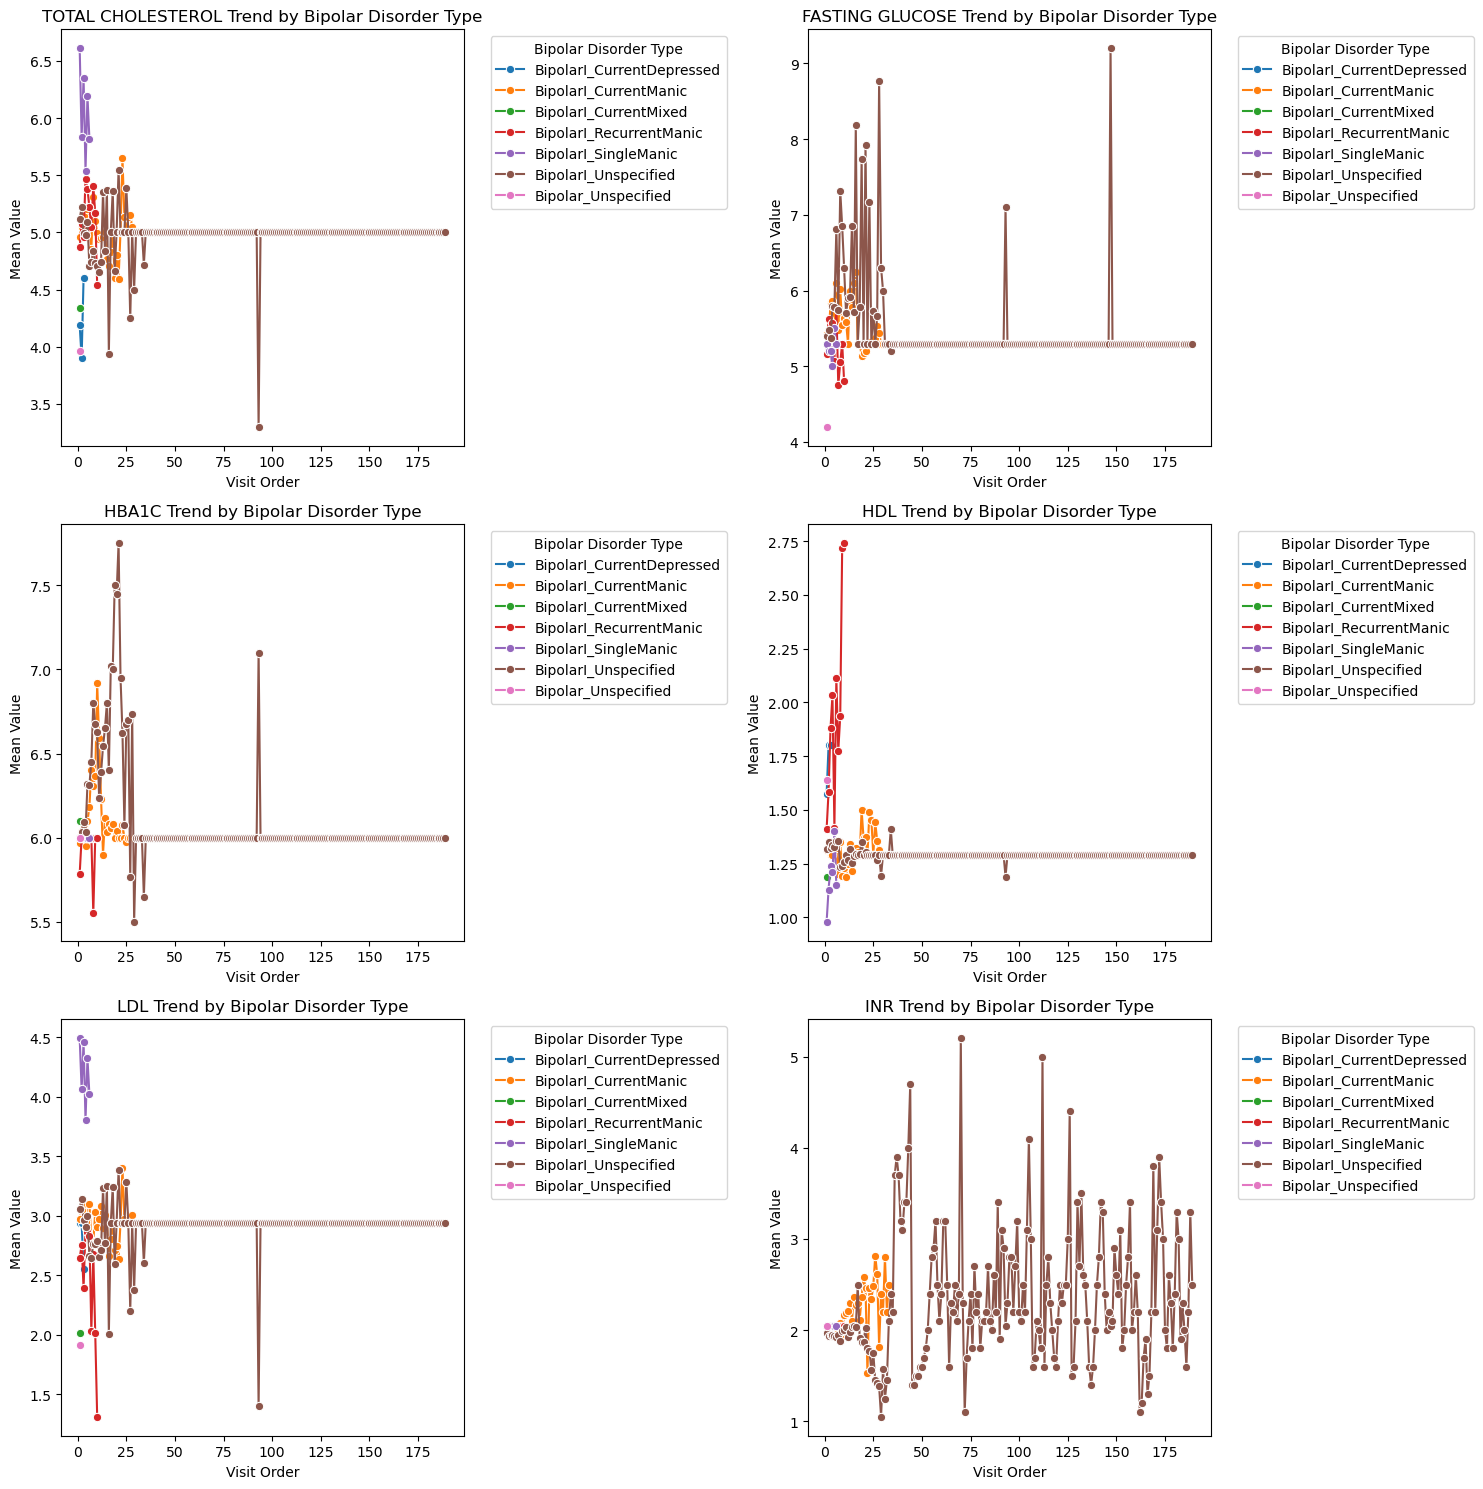

In [4]:
# Map and encode subtypes of bipolar disorders
bipolar_map = {
    '296.0': 'BipolarI_SingleManic',
    '296.1': 'BipolarI_RecurrentManic',
    '296.4': 'BipolarI_CurrentManic',
    '296.5': 'BipolarI_CurrentDepressed',
    '296.6': 'BipolarI_CurrentMixed',
    '296.7': 'BipolarI_Unspecified',
    '296.8': 'Bipolar_Unspecified'
}

bipolar_order = [
    'BipolarI_SingleManic',
    'BipolarI_RecurrentManic',
    'BipolarI_CurrentManic',
    'BipolarI_CurrentDepressed',
    'BipolarI_CurrentMixed',
    'BipolarI_Unspecified',
    'Bipolar_Unspecified'
]

df_all_vars = em.map_encode(
    data=df_all_vars,
    code='BD_Code',
    mapping_dict=bipolar_map,
    ordered_levels=bipolar_order,
    new_label='Bipolar Disorder Type',
    new_factor='Bipolar Disorder Type Factor',
    new_num='Bipolar Disorder Type Num'
)

# Visualize grouped trajctory of subtypes of bipolar disorders
em.plot_grouped_trends(
    data=df_all_vars,
    variables=['TOTAL CHOLESTEROL', 'FASTING GLUCOSE', 'HBA1C', 
            'HDL', 'LDL', 'INR'],
    group_x='VisitOrder',
    group_hue='Bipolar Disorder Type',
    xlabel='Visit Order',
    ylabel='Mean Value',
    title_prefix='',
)

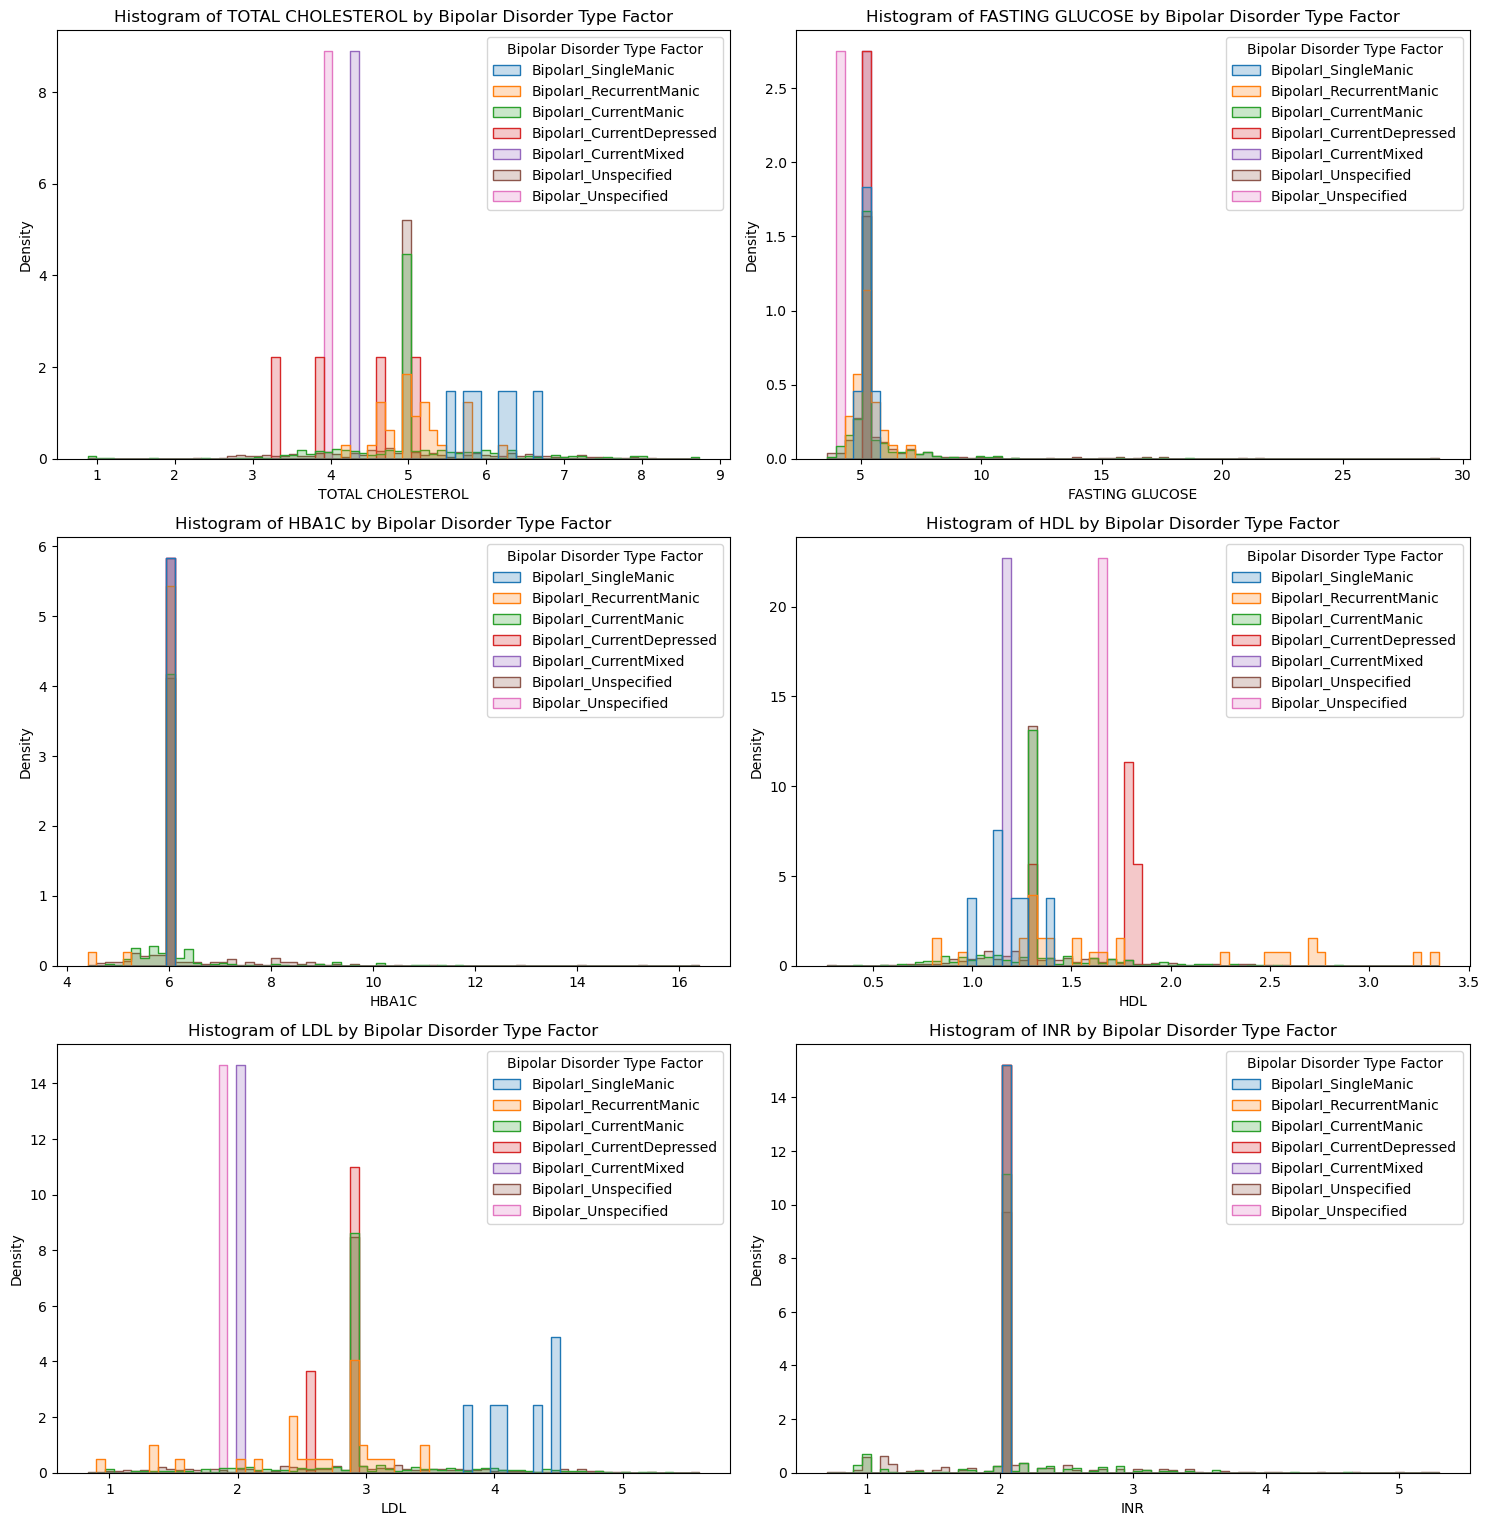

In [5]:
# EDA for bipolar disorder subtypes
em.plot_grouped_histograms(df_all_vars, 
                      variables = ['TOTAL CHOLESTEROL', 'FASTING GLUCOSE', 'HBA1C',
            'HDL', 'LDL', 'INR'], 
                      group='Bipolar Disorder Type Factor')

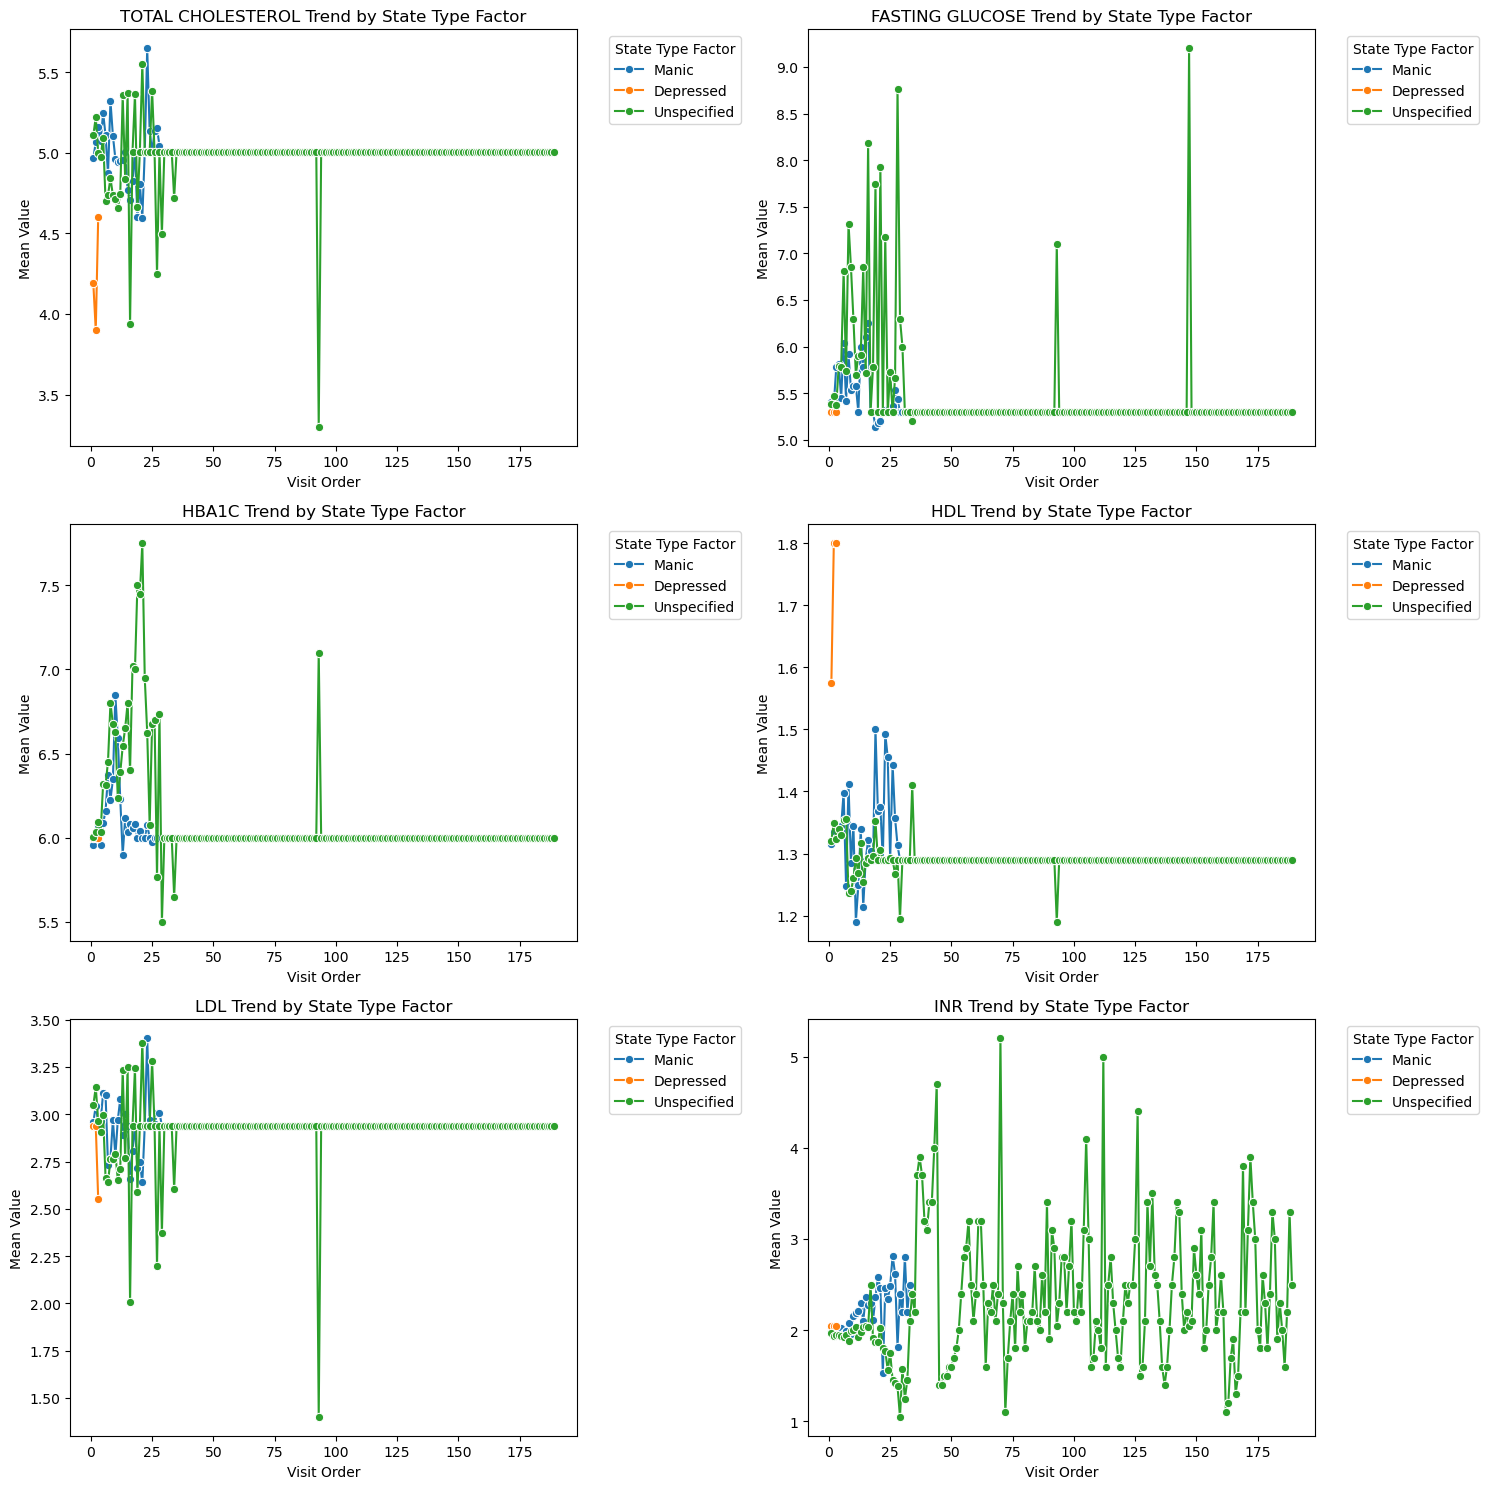

In [6]:
# Map and encode bipolar disorder states
state_map = {
    '296.0': 'Manic',         # BipolarI_SingleManic
    '296.1': 'Manic',         # BipolarI_RecurrentManic
    '296.4': 'Manic',         # BipolarI_CurrentManic
    '296.5': 'Depressed',     # BipolarI_CurrentDepressed
    '296.6': 'Manic',         # BipolarI_CurrentMixed (assigned to Manic, can adjust if needed)
    '296.7': 'Unspecified',   # BipolarI_Unspecified
    '296.8': 'Unspecified'    # Bipolar_Unspecified
}

state_order = ['Manic', 'Depressed', 'Unspecified']

df_all_vars = em.map_encode(
    data=df_all_vars,
    code='BD_Code',
    mapping_dict=state_map,
    ordered_levels=state_order,
    new_label='State Type',
    new_factor='State Type Factor',
    new_num='State Type Num'
)

# Visualize states of bipolar disorder
em.plot_grouped_trends(
    data=df_all_vars,
    variables=['TOTAL CHOLESTEROL', 'FASTING GLUCOSE', 'HBA1C', 
            'HDL', 'LDL', 'INR'],
    group_x='VisitOrder',
    group_hue='State Type Factor',
    xlabel='Visit Order',
    ylabel='Mean Value',
    title_prefix='',
)


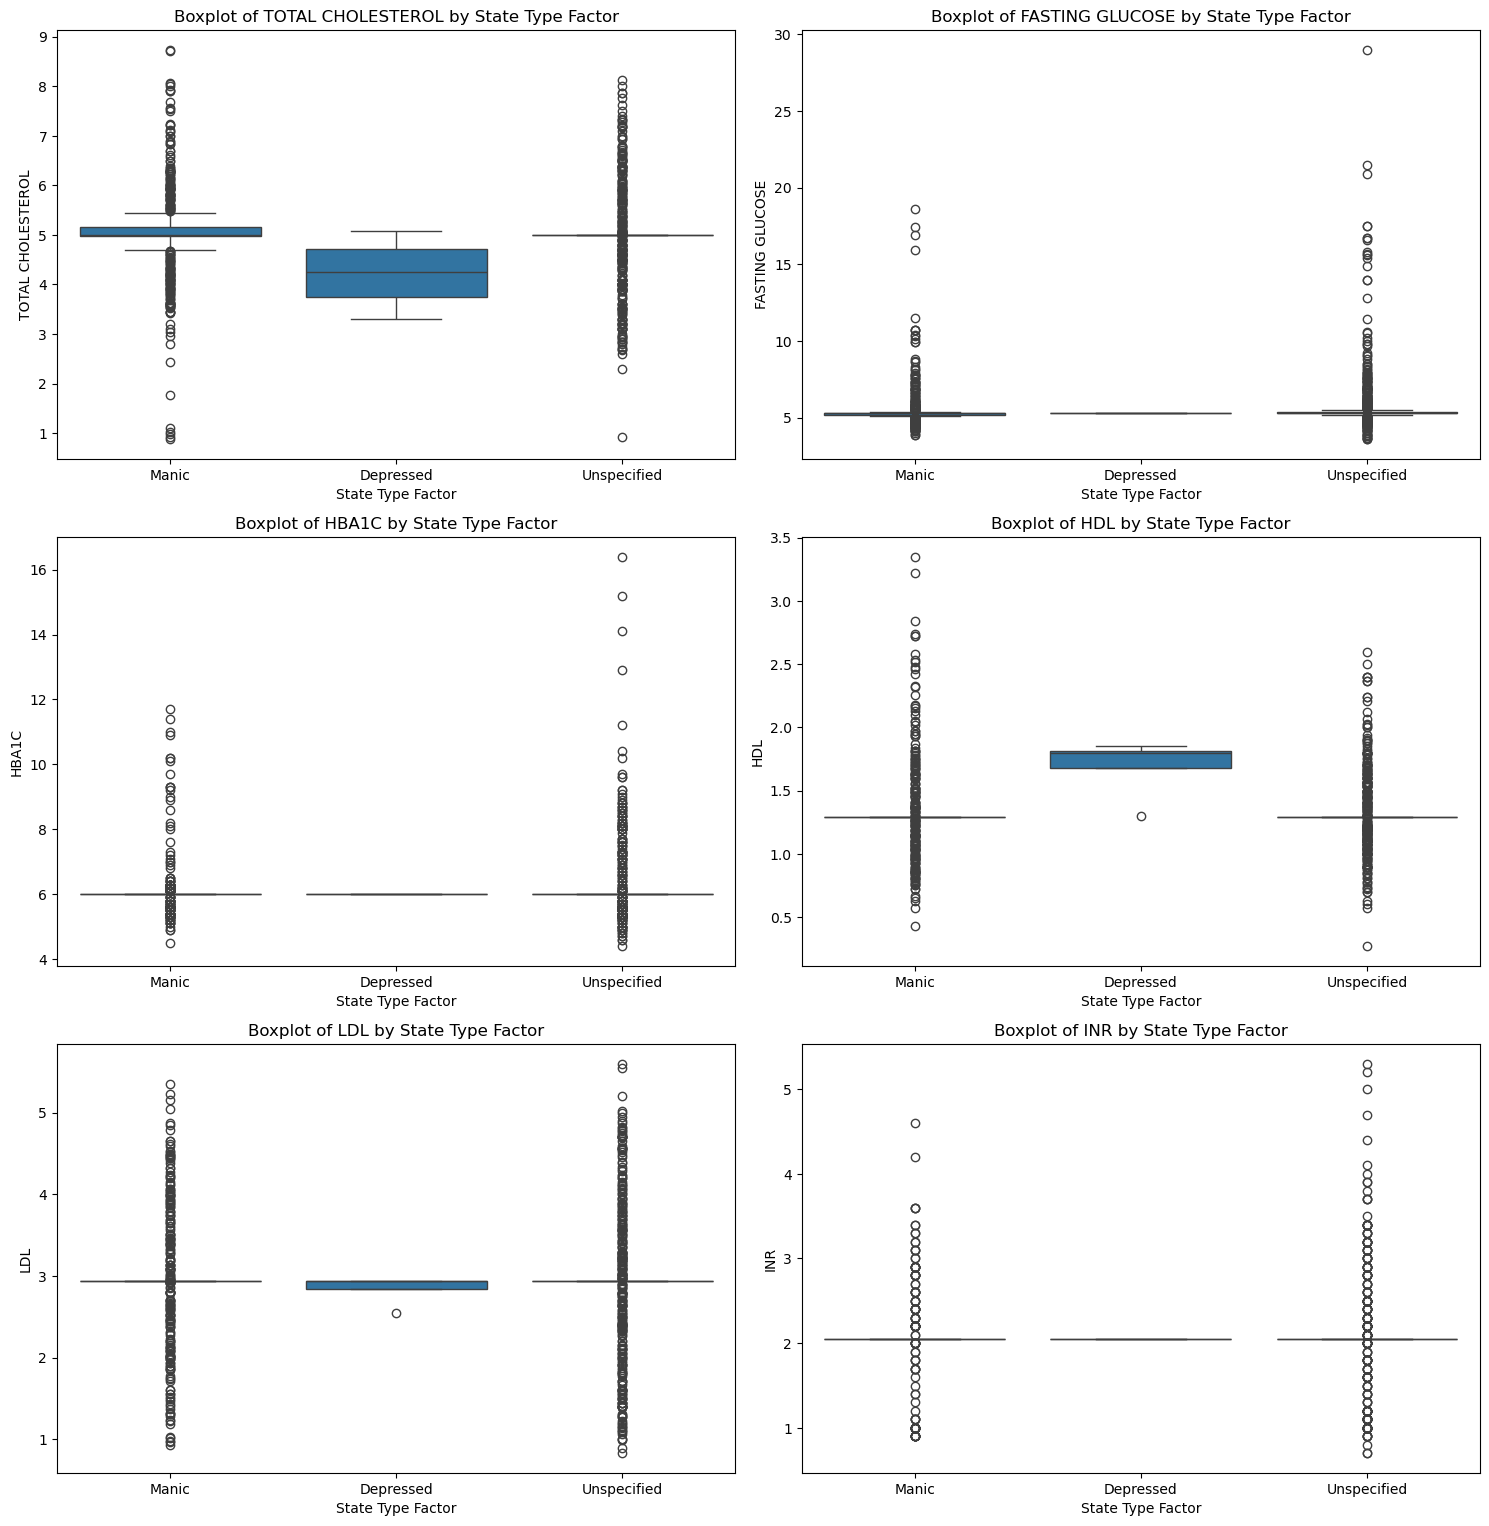

In [7]:
em.plot_grouped_boxplots(df_all_vars, 
                      variables = ['TOTAL CHOLESTEROL', 'FASTING GLUCOSE', 'HBA1C',
            'HDL', 'LDL', 'INR'], 
                      group='State Type Factor')

In [8]:
# Kruskal-Wallis Test to see whether there are significant differences in the variable across multiple State_factor groups
em.kruskal_test(df_all_vars, 
             variables= ['TOTAL CHOLESTEROL', 'FASTING GLUCOSE', 'HBA1C',
            'HDL', 'LDL', 'INR'], 
             group_col='Bipolar Disorder Type Factor')

TOTAL CHOLESTEROL: H=20.071, p=0.0005
FASTING GLUCOSE: H=4.750, p=0.1911
HBA1C: H=1.793, p=0.4079
HDL: H=34.036, p=0.0000
LDL: H=24.916, p=0.0001
INR: H=0.344, p=0.5573


,variable,n_groups,H_stat,p_value
0,TOTAL CHOLESTEROL,5,20.071203,4.834923e-04
1,FASTING GLUCOSE,4,4.749607,1.910775e-01
2,HBA1C,3,1.793431,4.079071e-01
3,HDL,5,34.036040,7.326133e-07
4,LDL,5,24.916176,5.230034e-05
5,INR,2,0.344360,5.573230e-01


In [9]:
em.kruskal_test(df_all_vars, 
             variables= ['TOTAL CHOLESTEROL', 'FASTING GLUCOSE', 'HBA1C',
            'HDL', 'LDL', 'INR'], 
             group_col='State Type Factor')

TOTAL CHOLESTEROL: H=5.496, p=0.0641
FASTING GLUCOSE: H=2.877, p=0.0899
HBA1C: H=1.301, p=0.2540
HDL: H=9.576, p=0.0083
LDL: H=0.496, p=0.7803
INR: H=0.333, p=0.5639


,variable,n_groups,H_stat,p_value
0,TOTAL CHOLESTEROL,3,5.495974,0.064057
1,FASTING GLUCOSE,2,2.876914,0.089858
2,HBA1C,2,1.301389,0.253960
3,HDL,3,9.576477,0.008327
4,LDL,3,0.496148,0.780302
5,INR,2,0.333044,0.563872



 Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       141
           1       0.93      0.98      0.96       141
           2       0.62      0.64      0.63       141
           5       0.63      0.58      0.61       141

    accuracy                           0.80       564
   macro avg       0.79      0.80      0.80       564
weighted avg       0.79      0.80      0.80       564

Confusion Matrix (Raw Counts):

[[140   0   0   1]
 [  0 138   1   2]
 [  1   5  90  45]
 [  1   5  53  82]]


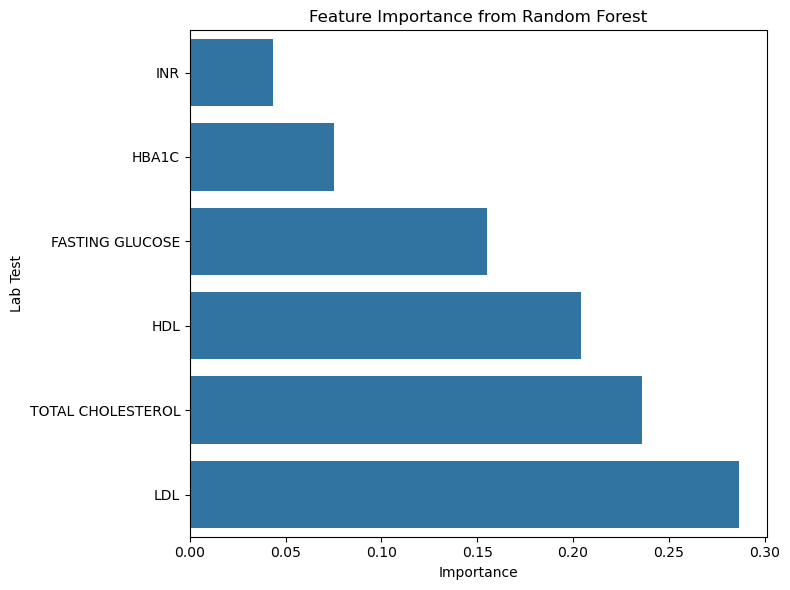


 Cross-Validated Precision: 0.758 ± 0.035


In [13]:
# Random forest

# Define lab test features 
lab_vars = ['TOTAL CHOLESTEROL', 'FASTING GLUCOSE', 'HBA1C', 'HDL', 'LDL', 'INR']
df_clean = df_all_vars.dropna(subset=['Bipolar Disorder Type Factor']).copy()
df_clean['Bipolar Disorder Type Factor'] = pd.Categorical(df_clean['Bipolar Disorder Type Factor']).codes

# Keep only classes with at least 5 samples
class_counts = df_clean['Bipolar Disorder Type Factor'].value_counts()
valid_classes = class_counts[class_counts >= 5].index.tolist()
df_filtered = df_clean[df_clean['Bipolar Disorder Type Factor'].isin(valid_classes)].copy()

X = df_filtered[lab_vars]
y = df_filtered['Bipolar Disorder Type Factor'].values

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Balance class distribution using SMOTE 
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)

# Split into train and test sets 
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, stratify=y_resampled, test_size=0.2, random_state=42
)

# Grid search for best hyperparameters
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

grid_search = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    param_grid,
    scoring='precision_macro',
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

# Evaluate the final model
best_rf = grid_search.best_estimator_
best_rf.fit(X_train, y_train)
y_pred = best_rf.predict(X_test)

print("\n Classification Report:\n")
print(classification_report(y_test, y_pred, zero_division=0))

print("Confusion Matrix (Raw Counts):\n")
print(confusion_matrix(y_test, y_pred))

# Feature importance plot 
importances = pd.Series(best_rf.feature_importances_, index=lab_vars).sort_values(ascending=True)

plt.figure(figsize=(8, 6))
sns.barplot(x=importances.values, y=importances.index)
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Lab Test")
plt.tight_layout()
plt.show()

# Cross-validated precision
cv_scores = cross_val_score(best_rf, X_resampled, y_resampled, cv=5, scoring='precision_macro')
print(f"\n Cross-Validated Precision: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")